In [1]:
# load some library
import numpy as np
import sys
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.dates import DateFormatter
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import sem
from calendar import Calendar
c = Calendar()
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import linregress
import xarray as xr
import netCDF4
#from google.colab.data_table import DataTable
#DataTable.max_columns = 40
import scikit_posthocs as sp
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
#import msfunctions

sys.path.append(os.path.expanduser('../../'))
from utils.functions import normalcy, pull_data, kruskal_drops
from utils.visuals import batch_bar, batch_bar_overlay, intertidal_box_plot

In [97]:
def process_abiotic_data(abiotic_data_path, start_date, end_date):
    """
    Processes multiple abiotic datasets, filters by date range, extracts relevant columns, and calculates 7-day and daily averages.

    Parameters:
    abiotic_data_path (str): The directory path where the datasets are stored.
    start_date (str): The start date in ISO format (e.g., '2022-08-01T00:00:00').
    end_date (str): The end date in ISO format (e.g., '2023-03-31T00:00:00').

    Returns:
    dict: A dictionary containing processed data from each dataset.
    dict: A dictionary containing 7-day averaged data for each dataset.
    dict: A dictionary containing daily averaged data for each dataset.
    """
    results = {}
    seven_day_averages = {}
    daily_averages = {}

    # Helper function to load, filter, and clean data
    def load_and_filter(file_name, date_col, additional_filters=None):
        data = pd.read_csv(abiotic_data_path + file_name)

        # Remove any 'Unnamed: _' columns
        data = data.loc[:, ~data.columns.str.contains('^Unnamed')] 

        # Clean column names by replacing spaces, parentheses, etc.
        data.columns = [col.replace('(', '_').replace(')', '').replace(' ', '_') for col in data.columns]

        data['date_time'] = pd.to_datetime(data[date_col])
        data = data[(data['date_time'] > start_date) & (data['date_time'] <= end_date)]
        if additional_filters:
            for condition in additional_filters:
                data = data[condition(data)]

        # Remove any columns with 'date', 'time', or 'datetime'
        data = data[[col for col in data.columns if col not in ['date', 'time', 'datetime']]]

        # Reorder columns to place 'date_time' first
        cols = ['date_time'] + [col for col in data.columns if col != 'date_time']
        data = data[cols]

        # Reset index
        data.reset_index(drop=True, inplace=True)

        return data

    def calculate_seven_day_average(data, base_name):
        # Use the `start_date` from the outer scope here
        averaged_data = data.copy()
        averaged_data.set_index('date_time', inplace=True)

        # Ensure the index is sorted by date_time
        averaged_data.sort_index(inplace=True)

        # Calculate 7-day rolling averages for all numeric columns
        rolling_avg = averaged_data.rolling('7D').mean()

        # Resample to keep one row every 7 days (align to start_date)
        seven_day_avg = rolling_avg.resample('7D', origin=start_date).mean()

        # Reset index to make date_time a column again
        seven_day_avg.reset_index(inplace=True)

        # Rename columns to indicate 7-day average
        seven_day_avg.columns = ['date_time'] + [f"{col}_seven_day_average" for col in seven_day_avg.columns if col != 'date_time']

        return seven_day_avg

    def calculate_daily_average(data):
        # Set 'date_time' as index for daily resampling
        averaged_data = data.copy()
        averaged_data.set_index('date_time', inplace=True)

        # Ensure the index is sorted by date_time
        averaged_data.sort_index(inplace=True)

        # Calculate daily averages for all numeric columns
        daily_avg = averaged_data.resample('D').mean()

        # Reset index to make date_time a column again
        daily_avg.reset_index(inplace=True)

        # Rename columns to indicate daily average
        daily_avg.columns = ['date_time'] + [f"{col}_daily_average" for col in daily_avg.columns if col != 'date_time']

        return daily_avg

    # Process datasets
    datasets = {
        'hobo': ('cleaned_rockaway_hobo_logger.csv', 'datetime', None),
        'star_oddi': ('cleaned_rockaway_star_oddi_salinity_data.csv', 'datetime', [lambda df: df['salinity_ppt'] > 5]),
        'fort_point_daily': ('fort_point_salinity_daily.csv', 'datetime', None),
        'fort_point_hourly': ('fort_point_salinity_hourly.csv', 'datetime', None),
        'precipitation': ('precipitation.csv', 'datetime', None)
    }

    for name, (file_name, date_col, filters) in datasets.items():
        data = load_and_filter(file_name, date_col, filters)
        results[name] = data

        # Calculate and store 7-day averages
        averaged_data_seven_day = calculate_seven_day_average(data, name)
        seven_day_averages[f"{name}_seven_day_average"] = averaged_data_seven_day

        # Calculate and store daily averages
        averaged_data_daily = calculate_daily_average(data)
        daily_averages[f"{name}_daily_average"] = averaged_data_daily

    # Print the names of resulting DataFrames
    print("Available datasets:")
    for name in results.keys():
        print(f"- {name}")

    print("\nAvailable 7-day average datasets:")
    for name in seven_day_averages.keys():
        print(f"- {name}")

    print("\nAvailable daily average datasets:")
    for name in daily_averages.keys():
        print(f"- {name}")

    # Now, return all three dictionaries
    return results, seven_day_averages, daily_averages

In [98]:
abiotic_data_path = 'C:/Users/jespi/sfsu-masters/sfsu-masters-anthopleura-sola/abiotic_data/'
start_date = '2022-08-01T00:00:00'
end_date = '2023-03-31T00:00:00'
data, seven_day_averages_data, daily_averages_data = process_abiotic_data(abiotic_data_path, start_date, end_date)

Available datasets:
- hobo
- star_oddi
- fort_point_daily
- fort_point_hourly
- precipitation

Available 7-day average datasets:
- hobo_seven_day_average
- star_oddi_seven_day_average
- fort_point_daily_seven_day_average
- fort_point_hourly_seven_day_average
- precipitation_seven_day_average

Available daily average datasets:
- hobo_daily_average
- star_oddi_daily_average
- fort_point_daily_daily_average
- fort_point_hourly_daily_average
- precipitation_daily_average


In [101]:
# Accessing the datasets
hobo_data = data['hobo']
star_oddi_data = data['star_oddi']
fort_point_daily_data = data['fort_point_daily']
fort_point_hourly_data = data['fort_point_hourly']
precipitation_data = data['precipitation']

hobo_seven_day_average_data = seven_day_averages_data['hobo_seven_day_average']
star_oddi_seven_day_average_data = seven_day_averages_data['star_oddi_seven_day_average']
fort_point_seven_day_average_data = seven_day_averages_data['fort_point_daily_seven_day_average']
fort_point_seven_day_hourly_average_data = seven_day_averages_data['fort_point_hourly_seven_day_average']
precipitation_seven_day_average_data = seven_day_averages_data['precipitation_seven_day_average']

hobo_average_data = daily_averages_data['hobo_daily_average']
star_oddi_average_data = daily_averages_data['star_oddi_daily_average']
fort_point_daily_average_data = daily_averages_data['fort_point_daily_daily_average']
fort_point_hourly_average_data = daily_averages_data['fort_point_hourly_daily_average']
precipitation_average_data = daily_averages_data['precipitation_daily_average']

# Setting up to retrieve satellite data

In [65]:
#@title
print('netcdf4-python version: %s'%netCDF4.__version__)

netcdf4-python version: 1.6.4


In [66]:
#@title
site_dict = {'ap': {'name' : 'Aramai Point',
        'lon' : -122.500725,
        'lat' : 37.607919,
        'Location' : 'Pacifica, San Mateo County, CA',
        'Site Description' : 'Aramai Point was originally named Rockaway Beach but has since been renamed to honor the Native American tribe that lived in the area for thousands of years. This public beach has hiking trails leading to prominent headlands that overshadow a rocky intertidal habitat below. The intertidal zone is very accessible, beginning a few hundred yards from the parking lot. Anemones, sea stars, tunicates, barnacles, and many other inverts are found throughout this site. Aramai Point is heavily trafficed by surfers, fishermen, and families, especially on the weekends.',
        'Research Conducted' : 'Identifying the impact intertidal positioning has on the symbiotic relationship between Anthopleura sola and their algal photosynthesizers.',
        'Student Researchers' : 'Jesse Espinoza'}
             }

In [67]:
#@title
stns = list(site_dict.keys())
print('Cohen field station keys:', stns)

Cohen field station keys: ['ap']


# Create lists of all lat and lon values

* Make empty lists that hold desired values
* Make a loop that goes through each station and holds its coordinate values


---



In [68]:
lats = []
lons = []
for stn in stns:
    lats.append(site_dict[stn]['lat']) #Filling up the latitude list by looping through our list of stations
    lons.append(site_dict[stn]['lon']) #Same but for longitude

print(lats)
print(lons)

[37.607919]
[-122.500725]


In [69]:
start_time = '2022-08-27T12:00:00'
end_time = '2023-04-22T12:00:00'

## Making variables to hold the URL's we are pointing at

---



In [70]:
#@title
mur_anom_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anom1day'
mur_sst_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41'

mur_anom_month_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anommday'
mur_sst_month__url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41mday'

# In case someone wants to look at upwelling data
upwell_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdQBstress3day_LonPM180'
#https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdUI36mo_LonPM180.html

## Open a pointer to open the dataset

* These new variables will hold all the data for that link
* We'll run one below so you can see what it looks like
---

In [71]:
#sst_anom = xr.open_dataset(mur_anom_url)
sst = xr.open_dataset(mur_sst_url)

month_sst_anom = xr.open_dataset(mur_anom_month_url)
month_sst = xr.open_dataset(mur_sst_month__url)

## Running sst variable

Returns the metadata which lets you know the dimensions and coordinates:
* Number of time values and range
* Latitude and Longitude values and range

Also shows the variables are in this dataset:
* analysed sst
* analysis error
* mast
* sea ice fraction

---

In [72]:
sst

<xarray.Dataset>
Dimensions:           (time: 8265, latitude: 17999, longitude: 36000)
Coordinates:
  * time              (time) datetime64[ns] 2002-06-01T09:00:00 ... 2025-01-1...
  * latitude          (latitude) float32 -89.99 -89.98 -89.97 ... 89.98 89.99
  * longitude         (longitude) float32 -180.0 -180.0 -180.0 ... 180.0 180.0
Data variables:
    analysed_sst      (time, latitude, longitude) float64 ...
    analysis_error    (time, latitude, longitude) float64 ...
    mask              (time, latitude, longitude) float32 ...
    sea_ice_fraction  (time, latitude, longitude) float64 ...
Attributes: (12/51)
    _NCProperties:              version=2,netcdf=4.7.4,hdf5=1.8.12
    acknowledgement:            Please acknowledge the use of these data with...
    cdm_data_type:              Grid
    comment:                    MUR = "Multi-scale Ultra-high Resolution"
    Conventions:                CF-1.6, COARDS, ACDD-1.3
    creator_email:              ghrsst@podaac.jpl.nasa.gov
    ...                         ...
    summary:                    This is a merged, multi-sensor L4 Foundation ...
    testOutOfDate:              now-3days
    time_coverage_end:          2025-01-17T09:00:00Z
    time_coverage_start:        2002-06-01T09:00:00Z
    title:                      Multi-scale Ultra-high Resolution (MUR) SST A...
    Westernmost_Easting:        -179.99

# Creating a small square area for satellite data to retrieve from, offshore about 5km

In [73]:
def site_sample_area(site):
  '''
  This function will take your sites coordinates and make the sample area while
  scooting a bit away from land. Then it will take those coordinates and apply
  them to a pointer (in this case sst), which has the variable selected and
  our time range in too.

  To do other pointers, this code can be expanded, or duplicated but for other
  variables

  site = dictionary site key, an abbreviation in quotation marks. Ex: 'ap'
  '''
  site_lon = site_dict[site]['lon']
  site_lon_min = site_lon - 2 * 0.04
  site_lon_max = site_lon - 0.04

  site_lat = site_dict[site]['lat']
  site_lat_min = site_lat - 2 * 0.04
  site_lat_max = site_lat - 0.04

  print('lon:', site_lon_min, site_lon_max) #uncomment if you want to see the coordinates per your site
  print('lat:', site_lat_min, site_lat_max)

  your_sst =sst['analysed_sst'].sel(
                    latitude=slice(site_lat_min, site_lat_max),
                    longitude=slice(site_lon_min, site_lon_max),
                    time=slice(start_time, end_time)
                    )

  return your_sst


In [74]:
ap_beach = site_sample_area('ap')

lon: -122.580725 -122.54072500000001
lat: 37.527919000000004 37.567919


In [89]:
star_oddi_data

,date_time,temp_c,salinity_ppt,conduct_mS/cm,velocity_m/sec
0,2022-08-13 08:20:00,16.52,31.66,40.61,1507.50
1,2022-08-13 08:40:00,16.61,31.63,40.66,1507.75
2,2022-08-13 09:00:00,16.74,31.63,40.76,1508.11
3,2022-08-13 09:20:00,16.92,31.51,40.79,1508.52
4,2022-08-13 09:40:00,17.07,31.27,40.65,1508.70
...,...,...,...,...,...
11301,2023-03-30 22:40:00,11.64,29.06,33.54,1488.35
11302,2023-03-30 23:00:00,11.64,29.10,33.59,1488.40
11303,2023-03-30 23:20:00,11.68,28.79,33.29,1488.14
11304,2023-03-30 23:40:00,11.68,28.77,33.27,1488.11


# Visualize SST from data loggers and satellite data

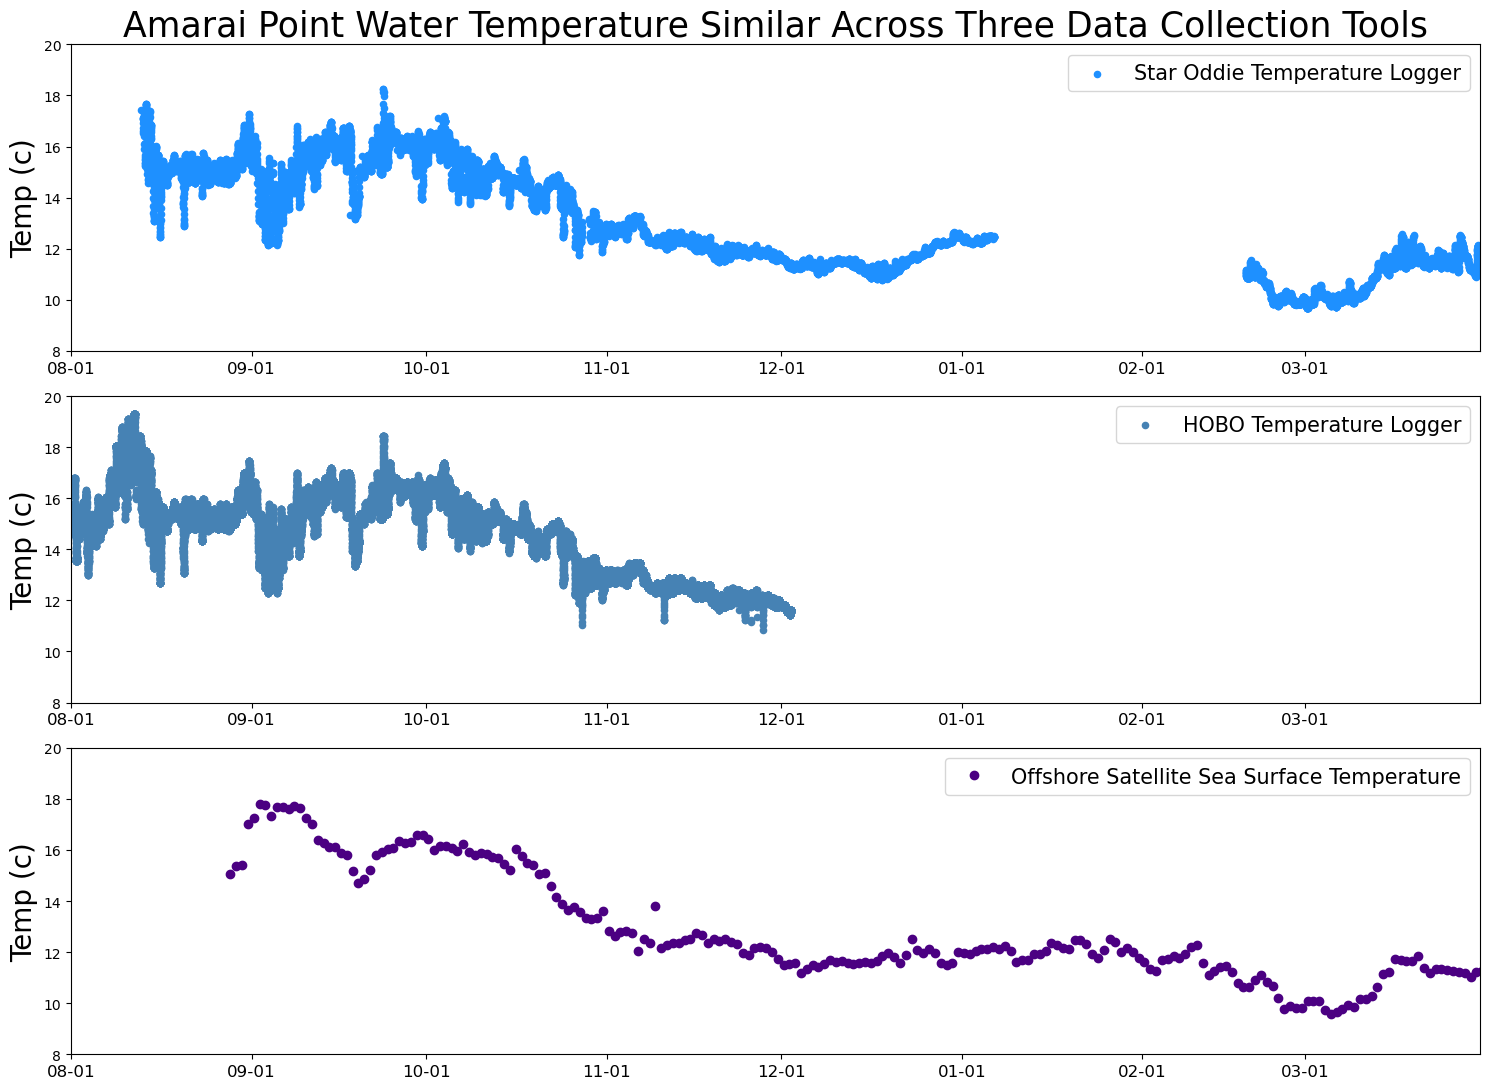

In [90]:
start_date = '2022-08-01'
end_date = '2023-03-31'

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharey=False, figsize=(15, 11))

ax1.scatter(star_oddi_data.date_time, star_oddi_data.temp_c, color='dodgerblue', zorder=2, s=20)
ax1.set(ylabel='Temp (c)', title='Amarai Point Water Temperature Similar Across Three Data Collection Tools',
        xlim=(start_date, end_date), ylim=(8, 20))
ax1.set_title('Amarai Point Water Temperature Similar Across Three Data Collection Tools', fontsize=25)
ax1.tick_params(axis='x', labelsize=12, labelbottom=True)
#ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax1.legend(('Star Oddie Temperature Logger',), loc='best', fontsize=15)

ax2.scatter(hobo_data.date_time, hobo_data.temp_c, color='steelblue', zorder=2, s=20)
ax2.set(ylabel='Temp (c)', xlim=(start_date, end_date), ylim=(8, 20))
ax2.tick_params(axis='x', labelsize=12, labelbottom=True)
#ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax2.legend(('HOBO Temperature Logger',), loc='best', fontsize=15)

ax3.plot(ap_beach.time, ap_beach.mean(axis=(1, 2)), 'o', label='Amarai Point', zorder=2, color='indigo')
ax3.set(ylabel='Temp (c)', xlim=(start_date, end_date), ylim=(8, 20))
ax3.tick_params(axis='x', labelsize=12, labelbottom=True)
#ax3.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax3.legend(('Offshore Satellite Sea Surface Temperature',), loc='best', fontsize=15)

# Adjust label sizes
for ax in [ax1, ax2, ax3]:
    ax.xaxis.label.set_size(20)
    ax.yaxis.label.set_size(20)
    #ax.grid(False)
plt.tight_layout()
plt.show()


In [103]:
hobo_average_data

,date_time,temp_f_daily_average,temp_c_daily_average
0,2022-08-01,60.244606,15.691448
1,2022-08-02,58.743399,14.857444
2,2022-08-03,59.142743,15.079302
3,2022-08-04,58.605910,14.781061
4,2022-08-05,59.209722,15.116512
...,...,...,...
119,2022-11-28,53.642781,12.023767
120,2022-11-29,53.417257,11.898476
121,2022-11-30,53.279156,11.821753
122,2022-12-01,53.108865,11.727147


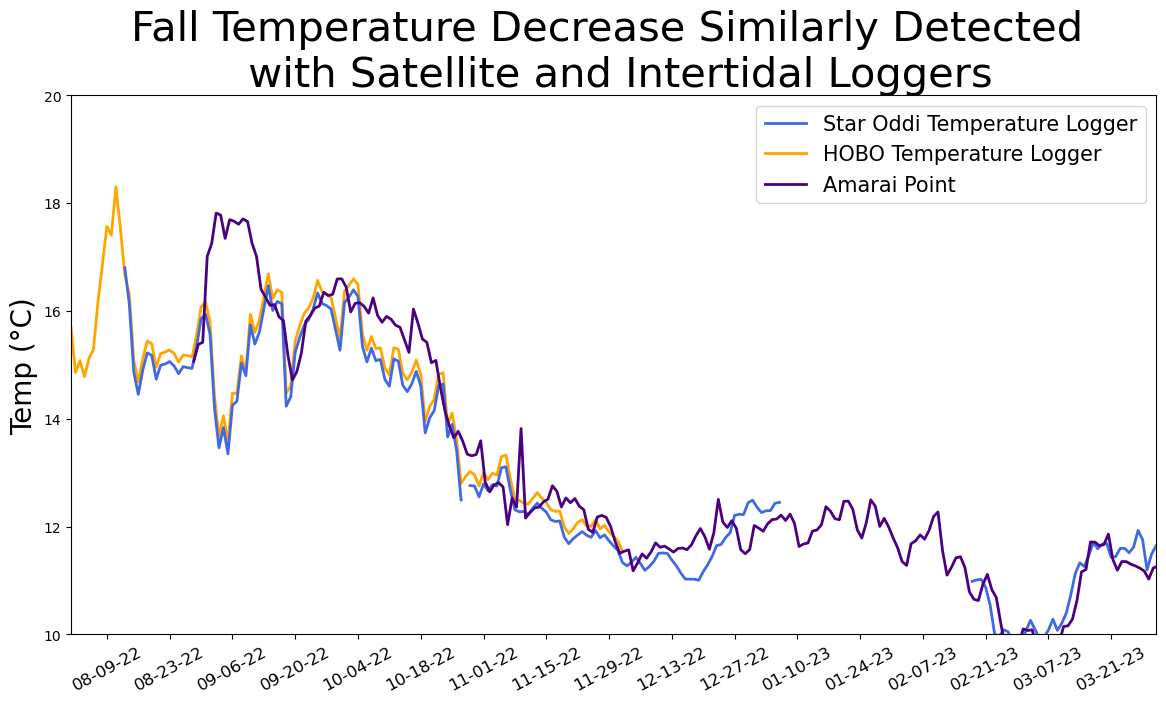

In [112]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

f, ax = plt.subplots(figsize=(14, 7))

# Plot line plots instead of scatter
ax.plot(star_oddi_average_data['date_time'], star_oddi_average_data['temp_c_daily_average'], 
        color='royalblue', label='Star Oddi Temperature Logger', linewidth=2, zorder=3)

ax.plot(hobo_average_data['date_time'], hobo_average_data['temp_c_daily_average'], 
        color='orange', label='HOBO Temperature Logger', linewidth=2, zorder=2)

ax.plot(ap_beach.time, ap_beach.mean(axis=(1,2)), label='Amarai Point', color='indigo', linewidth=2, zorder=6)

ax.set_title('Fall Temperature Decrease Similarly Detected \n with Satellite and Intertidal Loggers', fontsize=30)
ax.set_ylabel('Temp (°C)', fontsize=20)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=12, rotation=28, labelbottom=True)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)
ax.set_ylim(10, 20)

# Adjusting legend
lgnd = ax.legend(loc='best', fontsize=15)
lgnd.legendHandles[0]._sizes = [30]
lgnd.legendHandles[1]._sizes = [30]

ax.grid(False)  # Enable grid for line plot

plt.show()


# Plotting salinty and rain

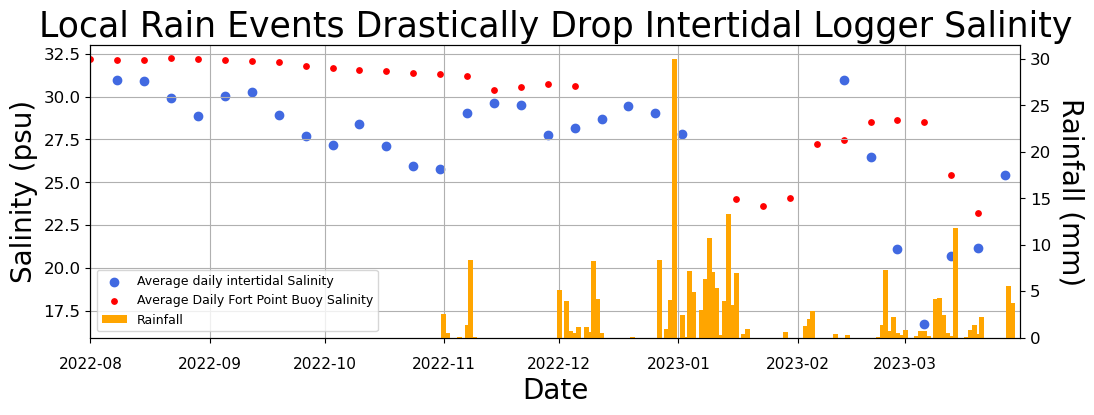

In [95]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.scatter(star_oddi_average_data['date_time'], star_oddi_average_data['salinity_ppt_seven_day_average'], color = 'royalblue', label = 'Average daily intertidal Salinity')
ax.set(xlabel = "Date", ylabel='Salinity (psu)')
ax.set_title('Local Rain Events Drastically Drop Intertidal Logger Salinity', fontsize =25)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=10)
ax.tick_params(axis='y', labelsize=12)
#ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)
ax.grid(True)

ax2 = ax.twinx() #to plot a second y axis
ax2.bar(precipitation_data['date_time'], precipitation_data['rain_mm'], width = 1.3, color = 'orange', label = 'Rainfall')
plt.ylabel('Rainfall (mm)', fontsize=12, rotation= 270, va="bottom")
#ax2.set(ylabel='Rainfall (mm)')
ax2.set_xlim(start_date, end_date)
ax2.tick_params(axis='y', labelsize=12)
ax2.yaxis.label.set_size(20)
ax2.grid(False)

#ax3 = ax.twinx()
ax.scatter(fort_point_daily_average_data['date_time'], fort_point_daily_average_data['salinity_ppt_seven_day_average'], color='red', s=15, label = 'Average Daily Fort Point Buoy Salinity')
ax.set_xlim(start_date, end_date)
#below code will show your legend for two y axis together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='lower left', fontsize = 9)